##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [48]:
!pip install -q opencv-python-headless matplotlib scikit-learn tensorflow yt-dlp

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\khulo\\anaconda3\\envs\\cv_lab\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [63]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

In [64]:
# Set seed for consistent results
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print(f"Seed set to: {seed_constant}")

Seed set to: 23


In [51]:

DATASET_DIR = r"C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab07-action-recognition\action_youtube_naudio"


all_classes = [cls for cls in os.listdir(DATASET_DIR) if not cls.startswith('.')]

print("=" * 50)
print("Available Classes in Dataset:")
for cls in all_classes:
    print(f"  - {cls}")
print("=" * 50)

Available Classes in Dataset:
  - basketball
  - biking
  - readme.txt
  - tennis_swing


In [65]:

CLASSES_LIST = ["basketball", "biking", "tennis_swing"]
print(f"Selected Classes: {CLASSES_LIST}")

image_height, image_width = 64, 64
max_images_per_class = 8000
model_output_size = len(CLASSES_LIST)

def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    while True:
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)
    video_reader.release()
    return frames_list

def create_dataset():
    temp_features = []
    features = []
    labels = []
    class_frame_counts = {}

    for class_index, class_name in enumerate(CLASSES_LIST):
        class_path = os.path.join(DATASET_DIR, class_name)

        if not os.path.exists(class_path):
            print(f"Warning: {class_name} folder missing!")
            continue

        for root, dirs, files in os.walk(class_path):
            for file_name in files:
                if file_name.lower().endswith((".mpg", ".avi", ".mp4", ".mov")):
                    video_file_path = os.path.join(root, file_name)
                    frames = frames_extraction(video_file_path)
                    temp_features.extend(frames)

        class_frame_counts[class_name] = len(temp_features)
        
        if len(temp_features) > 0:
            sample_size = min(len(temp_features), max_images_per_class)
            features.extend(random.sample(temp_features, sample_size))
            labels.extend([class_index] * sample_size)
            temp_features.clear()

    # Summary Table
    print("=" * 45)
    print(f"{'Class':<25} {'Total Frames':>12} {'Sampled':>6}")
    print("=" * 45)
    for cls, count in class_frame_counts.items():
        sampled = min(count, max_images_per_class)
        print(f"{cls:<25} {count:>12,} {sampled:>6,}")
    print("=" * 45)

    return np.asarray(features), np.array(labels)

# Process the existing folders
features, labels = create_dataset()
if len(labels) > 0:
    one_hot_encoded_labels = to_categorical(labels)
else:
    print("Error: No frames extracted. Please check the video files inside folders.")

Selected Classes: ['basketball', 'biking', 'tennis_swing']
Class                     Total Frames Sampled
basketball                      15,092  8,000
biking                          25,272  8,000
tennis_swing                    24,096  8,000


In [54]:
# Split the dataset into training (80%) and testing (20%) sets
features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels, test_size=0.2, shuffle=True, random_state=seed_constant)

# Print the final counts
print(f"Training samples : {len(features_train):,}")
print(f"Testing samples  : {len(features_test):,}\n")

Training samples : 19,200
Testing samples  : 4,800



In [66]:
def create_model():
    """Builds a CNN model for image-level action recognition."""
    model = Sequential()
    
    # Feature Extraction
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(image_height, image_width, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Global average pooling to reduce dimensionality
    model.add(GlobalAveragePooling2D())
    
    # Fully Connected Layers
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    
    # Output Layer: size matches the number of selected classes
    model.add(Dense(model_output_size, activation='softmax'))
    
    model.summary()
    return model

# Initialize the model
model = create_model()

c:\Users\khulo\anaconda3\envs\cv_lab\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

In [56]:
# Define early stopping to prevent overfitting
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    mode='min', 
    restore_best_weights=True
)

# Compile the model with Adam optimizer
model.compile(
    loss='categorical_crossentropy', 
    optimizer='Adam', 
    metrics=["accuracy"]
)

# Start training
model_training_history = model.fit(
    x=features_train, 
    y=labels_train,
    epochs=30, 
    batch_size=4,
    shuffle=True, 
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 242s 61ms/step - accuracy: 0.6758 - loss: 0.7386 - val_accuracy: 0.7633 - val_loss: 1.0318
Epoch 2/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 173s 45ms/step - accuracy: 0.8380 - loss: 0.4283 - val_accuracy: 0.8841 - val_loss: 0.3276
Epoch 3/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 170s 44ms/step - accuracy: 0.8831 - loss: 0.3192 - val_accuracy: 0.8742 - val_loss: 0.4419
Epoch 4/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 176s 46ms/step - accuracy: 0.9046 - loss: 0.2681 - val_accuracy: 0.9138 - val_loss: 0.2746
Epoch 5/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 188s 49ms/step - accuracy: 0.9187 - loss: 0.2307 - val_accuracy: 0.9716 - val_loss: 0.0997
Epoch 6/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 258s 67ms/step - accuracy: 0.9281 - loss: 0.2078 - val_accuracy: 0.9688 - val_loss: 0.0883
Epoch 7/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 262s 68ms/step - accuracy: 0.9364 - loss: 0.1848 - val_accuracy: 0.9828 - val_loss: 0.0608
Epoch 8/30
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 249s 65ms/step - accuracy: 

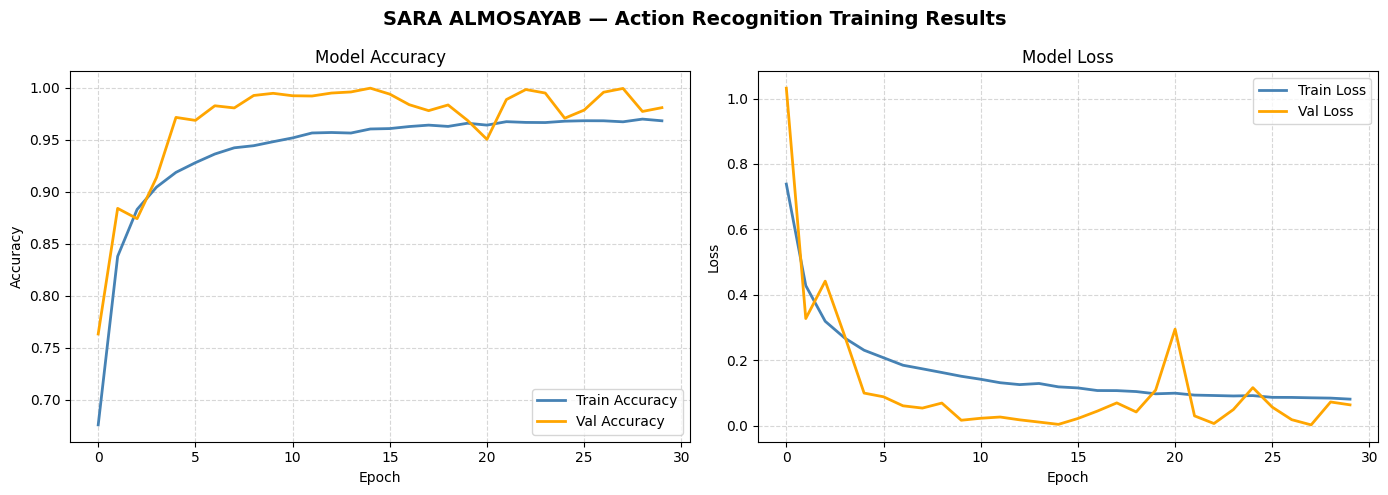

In [57]:
# Create subplots for Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SARA ALMOSAYAB — Action Recognition Training Results', fontsize=14, fontweight='bold')

# Accuracy Plot
axes[0].plot(model_training_history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(model_training_history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Loss Plot
axes[1].plot(model_training_history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(model_training_history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# Save the plot with your name
plt.savefig('SARA_ALMOSAYAB_training_plot.png', dpi=150)
plt.show()

In [58]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(features_test, labels_test)

# Results table with your name
print("\n" + "=" * 40)
print("         TEST EVALUATION RESULTS")
print("        SARA ALMOSAYAB — ARTI560")
print("=" * 40)

results_df = pd.DataFrame({
    'Metric': ['Test Loss', 'Test Accuracy'],
    'Value': [f"{loss:.4f}", f"{accuracy * 100:.2f}%"]
})

print(results_df.to_string(index=False))
print("=" * 40)

150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9994 - loss: 0.0030

         TEST EVALUATION RESULTS
        SARA ALMOSAYAB — ARTI560
       Metric  Value
    Test Loss 0.0030
Test Accuracy 99.94%


In [ ]:
student_name = "SARA_ALMOSAYAB"
save_path = f"{student_name}_action_model.h5"

# Save the trained model to a file
model.save(save_path)

print(f"\nModel saved as: {save_path}\n")


Model saved as: SARA_ALMOSAYAB_action_model.h5



In [67]:
from tensorflow.keras.models import load_model
# Run this to load your PREVIOUSLY trained weights
model = load_model('SARA_ALMOSAYAB_action_model.h5')

In [73]:
import numpy as np
import os

# 1. Initialize the list to store results for the chart
test_results = []

def predict_video(video_path):
    try:
        frames = frames_extraction(video_path) 
        
        if frames is None or len(frames) == 0:
            return None

        target_frame = frames[len(frames)//2] 
        input_data = np.expand_dims(target_frame, axis=0) 

        prediction = model.predict(input_data, verbose=0)
        
        predicted_class_index = np.argmax(prediction)
        confidence = prediction[0][predicted_class_index]
        
        predicted_class_name = CLASSES_LIST[predicted_class_index]
        
        return predicted_class_name, confidence

    except Exception as e:
        print(f"Technical Error Details: {e}")
        return None

# --- Test Section ---

local_test_videos = {
    "basketball": r"C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab07-action-recognition\basketball.mp4",
    "biking": r"C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab07-action-recognition\biking.mp4",
    "tennis_swing": r"C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab07-action-recognition\tennis_swing.mp4"
}

print("=" * 60)
print(f"{'Video File':<25} {'Predicted Action':<22} {'Confidence':>10}")
print("=" * 60)

for original_class, video_path in local_test_videos.items():
    if os.path.exists(video_path):
        result = predict_video(video_path)
        if result:
            predicted_class, confidence = result
            print(f"{original_class:<25} {predicted_class:<22} {confidence*100:>9.2f}%")
            
            # 2. Save the result into the list for the plotting code
            test_results.append({
                'predicted': f"{original_class} ({predicted_class})", 
                'confidence': confidence * 100
            })
        else:
            print(f"{original_class:<25} {'Error':<22} {'0.00%':>10}")
    else:
        print(f"{original_class:<25} {'File Not Found':<22} {'N/A':>10}")

print("=" * 60)

Video File                Predicted Action       Confidence
basketball                basketball                 74.54%
biking                    biking                     98.99%
tennis_swing              tennis_swing              100.00%


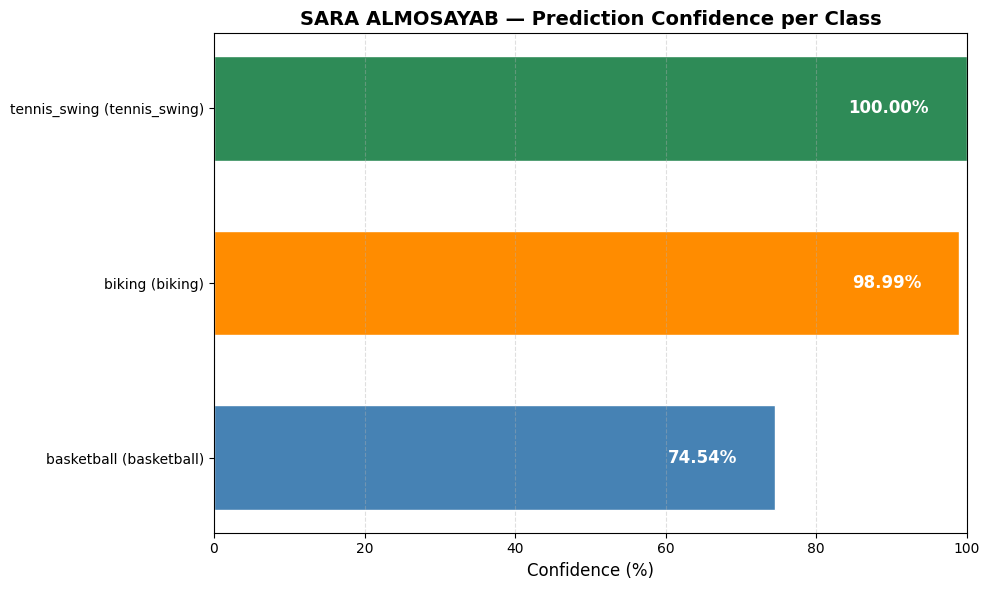

In [74]:
import matplotlib.pyplot as plt

if test_results:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define colors for the bars
    colors = ['#4682B4', '#FF8C00', '#2E8B57']
    
    classes = [r['predicted'] for r in test_results]
    confidences = [r['confidence'] for r in test_results]
    
    bars = ax.barh(classes, confidences, color=colors[:len(test_results)], edgecolor='white', height=0.6)

    # Add text labels inside the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width - 5, bar.get_y() + bar.get_height()/2, 
                f"{width:.2f}%", 
                va='center', ha='right', color='white', 
                fontweight='bold', fontsize=12)

    # Formatting the chart
    ax.set_xlim(0, 100)
    ax.set_xlabel('Confidence (%)', fontsize=12)
    ax.set_title('SARA ALMOSAYAB — Prediction Confidence per Class', fontweight='bold', fontsize=14)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    # Save the plot
    plt.savefig('SARA_ALMOSAYAB_predictions.png', dpi=150)
    plt.show()
else:
    print("No prediction results to plot. Please run the table cell first.")